In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
from scipy.sparse import csr_matrix
from sklearn.linear_model import LinearRegression
import pandas as pd

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [3]:
def convert_to_sparse(data):
    for column in data.select_dtypes(include=['object']):
        data[column] = data[column].map(lambda x: eval(x) if isinstance(x, str) else x)
    return csr_matrix(data.values)

X_train = convert_to_sparse(X_train)
X_test = convert_to_sparse(X_test)

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Метрики модели линейной регрессии:")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

Метрики модели линейной регрессии:
MAE: 3.74472108003822
MSE: 24.743927928971647
R2 Score: 0.7138127626121498


In [7]:
import json

metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

with open("C:/Users/kseni/PycharmProjects/tpu-8e21-ai-basis/Fomina/jupyter/metrics/linear_regression_metrics.json", "w") as f:
    json.dump(metrics, f)

In [8]:
import pickle

with open("C:/Users/kseni/PycharmProjects/tpu-8e21-ai-basis/Fomina/jupyter/models/linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

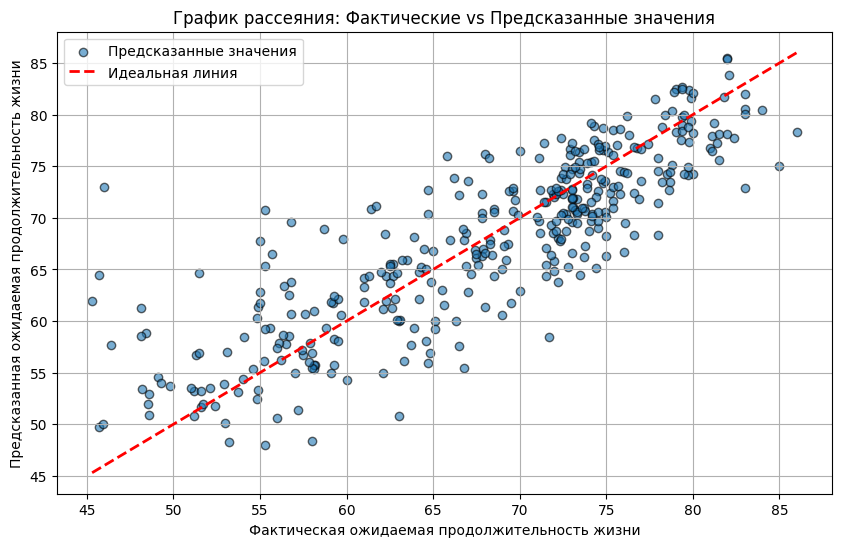

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k', label='Предсказанные значения')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Идеальная линия")
plt.xlabel('Фактическая ожидаемая продолжительность жизни')
plt.ylabel('Предсказанная ожидаемая продолжительность жизни')
plt.title('График рассеяния: Фактические vs Предсказанные значения')
plt.legend()
plt.grid(True)

plt.savefig(r"C:/Users/kseni/PycharmProjects/tpu-8e21-ai-basis/Fomina/jupyter/models/linear_regression/1.png", dpi=300, bbox_inches="tight")

plt.show()